## 1 Import the CSV data and required packages

In [9]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2 Label Encoding

In [4]:
# from sklearn.preprocessing import LabelEncoder library is used to convert strings to numerical followed by operation of euclidean distance

# Apply Label Encoding to all object (string) columns
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head(7)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
5,6551,0,0,0,0,8,1,2,1,0,...,2,0,2,2,0,1,2,99.65,6104,1
6,1002,1,0,0,1,22,1,2,1,0,...,0,0,2,0,0,1,1,89.10,1550,0


## 3 Set X and Y

In [6]:
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]
nrows = df.shape[0] # Number of rows in the dataset

## 4 Model Training

In [7]:
# np.random.seed(59) # acts likes random_state without train_test_split sklearn library

# select top 12 most important features using Random Forest
rf_temp = RandomForestClassifier(n_estimators=100, random_state=53)
rf_temp.fit(x, y)
feature_importance = pd.Series(rf_temp.feature_importances_, index=x.columns).sort_values(ascending=False)
top_features = feature_importance.head(12).index
x = x[top_features]


# handle class imbalance using SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=53)
over_sampler = RandomOverSampler(sampling_strategy=1, random_state=53)

# Create a pipeline
pipeline = Pipeline([('smote', smote), ('over_sampler', over_sampler)])

x_resampled, y_resampled = pipeline.fit_resample(x, y)

# Check new class distribution
print("Resampled class distribution:", Counter(y_resampled))


x_train,x_test,y_train,y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, stratify = y_resampled, random_state = 53)

# scale features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



print("y_resampled train after stratify:", Counter(y_train))
print("y_resampled test after stratify:", Counter(y_test))



# sklearn inbuilt KNN
model = KNeighborsClassifier(n_neighbors=1, weights = 'distance')
model.fit(x_train, y_train)


# Storing the predictions from our test data
pred = model.predict(x_test)
# Calculating the accuracy of the model
accuracy = accuracy_score(y_test, pred)

Resampled class distribution: Counter({0: 5174, 1: 5174})
y_resampled train after stratify: Counter({0: 4139, 1: 4139})
y_resampled test after stratify: Counter({0: 1035, 1: 1035})


## 5 Model Evaluation

------------------------------------------------------------------------------------------------------------------------------------------------------
Predictions: [0 1 0 ... 1 0 0]
Model Accuracy: 84.59% 
------------------------------------------------------------------------------------------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.81      0.90      0.85      1035

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070

------------------------------------------------------------------------------------------------------------------------------------------------------


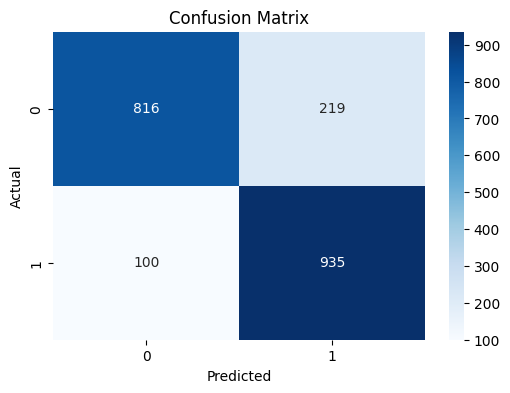

In [10]:
print("------------------------------------------------------------------------------------------------------------------------------------------------------")
print("Predictions:", pred)
print(f"Model Accuracy: {accuracy*100:.2f}% ")
print("------------------------------------------------------------------------------------------------------------------------------------------------------")
print("\nClassification Report:\n", classification_report(y_test, pred))
print("------------------------------------------------------------------------------------------------------------------------------------------------------")
# confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()